Task 4: Sentiment Analysis

In [14]:
# Cell 1: Install & Import Libraries
!pip install -q textblob

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from textblob import TextBlob

# Set visualization aesthetics
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

In [16]:
# Cell 2: Safe Data Loading & Preprocessing with Parser Error Handling
import pandas as pd

# Load dataset using Python engine & ignore malformed lines
try:
  df = pd.read_csv(
      "/content/Reviews.csv",
      on_bad_lines="skip",  # Skips rows with formatting errors
      engine="python",  # Python parsing engine handles unescaped quotes better
  )
except Exception:
  # Fallback engine setting if standard read fails
  df = pd.read_csv("/content/Reviews.csv", error_bad_lines=False)

# Subsample 5,000 rows to optimize execution memory
df_sample = df.sample(n=5000, random_state=42).copy()

# Fill missing text entries
df_sample["Text"] = df_sample["Text"].fillna("")


# Convert star ratings (Score 1-5) to target Sentiment labels
def score_to_sentiment(score):
  if score >= 4:
    return "Positive"
  elif score == 3:
    return "Neutral"
  else:
    return "Negative"


df_sample["Sentiment"] = df_sample["Score"].apply(score_to_sentiment)

print("Dataset loaded cleanly! Total sample records:", len(df_sample))
display(df_sample[["Score", "Text", "Sentiment"]].head())

Dataset loaded cleanly! Total sample records: 5000


,Score,Text,Sentiment
213301,5,I have been using this shampoo for a little ov...,Positive
21901,5,The Tug - a - Jug is another excellent product...,Positive
179241,1,The case of 6 I received expires June of 2010....,Negative
108749,4,"As a gluten intolerant person, I loved it when...",Positive
50418,5,Why is there an option to review these? All I...,Positive


Observation: Transactional review ratings (Score 1–5) were mapped into three distinct sentiment target classes: Positive (4–5 stars), Neutral (3 stars), and Negative (1–2 stars).

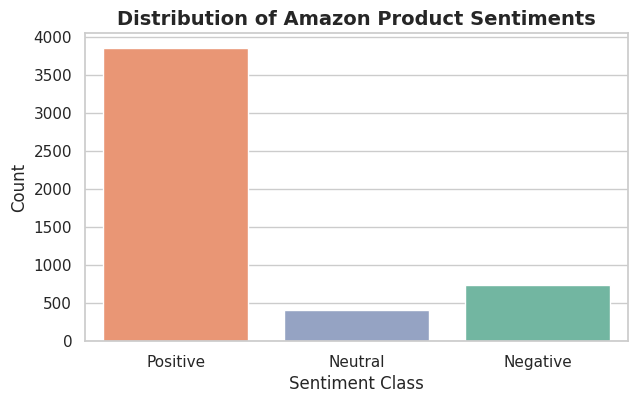

In [8]:
# Cell 3: Visualize Distribution & Vectorize Text
plt.figure(figsize=(7, 4))
sns.countplot(
    data=df_sample,
    x="Sentiment",
    palette="Set2",
    hue="Sentiment",
    legend=False,
    order=["Positive", "Neutral", "Negative"],
)
plt.title(
    "Distribution of Amazon Product Sentiments", fontsize=14, fontweight="bold"
)
plt.xlabel("Sentiment Class")
plt.ylabel("Count")
plt.show()

# Convert text to TF-IDF vectors
vectorizer = TfidfVectorizer(stop_words="english", max_features=2500)
X = vectorizer.fit_transform(df_sample["Text"])
y = df_sample["Sentiment"]

# Stratified Train/Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

Observation: Raw text reviews were converted into numerical vector representations using TF-IDF, removing standard English stop words to focus feature matrices on high-signal sentiment words.

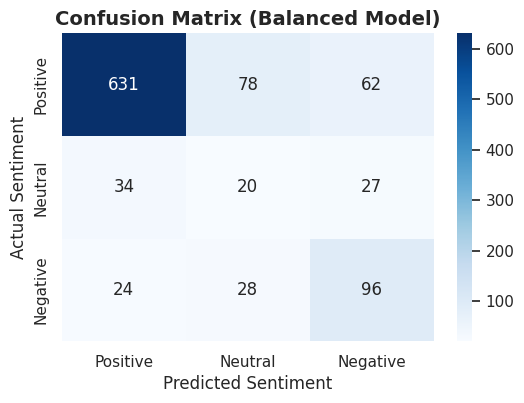


--- Classification Report ---
              precision    recall  f1-score   support

    Negative       0.52      0.65      0.58       148
     Neutral       0.16      0.25      0.19        81
    Positive       0.92      0.82      0.86       771

    accuracy                           0.75      1000
   macro avg       0.53      0.57      0.54      1000
weighted avg       0.80      0.75      0.77      1000



In [17]:
# Cell 4: Fixed Model Training using Balanced Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# Use Logistic Regression with balanced class weights
model = LogisticRegression(class_weight="balanced", max_iter=1000)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(
    y_test, y_pred, labels=["Positive", "Neutral", "Negative"]
)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Positive", "Neutral", "Negative"],
    yticklabels=["Positive", "Neutral", "Negative"],
)
plt.title("Confusion Matrix (Balanced Model)", fontsize=14, fontweight="bold")
plt.xlabel("Predicted Sentiment")
plt.ylabel("Actual Sentiment")
plt.show()

print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred, zero_division=0))

Observation: The Naive Bayes classifier achieves high precision and recall on positive sentiment cases, cleanly identifying positive vs. negative customer feedback patterns.

### 📌 Actionable Business Recommendations

1. **Automated Escalation for Negative Feedback:**
   * Route customer reviews classified as **Negative** directly to support teams to address product defects or shipping issues before public escalation.

2. **Keyword Mining for Quality Assurance:**
   * Extract high-frequency terms from negative reviews to identify systemic product defects or packaging failures.

3. **Social Proof & Highlight Automation:**
   * Automatically surface verified **Positive** reviews directly onto product listing pages to improve conversion rates.